In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [2]:
df = pd.read_csv("smart_home_device_data_repository.csv")
df.head()

,timestamp,device_id,temperature,power_consumption,user_activity,device_mode,anomaly_flag,decision_label
0,01-01-22 0:00,1358,19.040259,351.178701,Sleep,Standby,1,Normal
1,01-01-22 1:00,1630,18.915730,304.680342,Idle,Standby,0,Normal
2,01-01-22 2:00,1653,24.208691,337.412826,Active,Auto,0,Normal
3,01-01-22 3:00,1073,27.079689,126.721193,Sleep,Auto,0,Warning
4,01-01-22 4:00,1663,18.689548,390.740941,Idle,Standby,0,Normal


In [6]:
X = df[
    ["temperature",
     "power_consumption",
     "user_activity",
     "device_mode"]
]

y = df["decision_label"]



In [7]:
encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = encoder.fit_transform(X[col])

y = encoder.fit_transform(y)


/tmp/ipython-input-2214841308.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
/tmp/ipython-input-2214841308.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}


In [11]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ])


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

results_df.to_csv("model_results.csv", index=False)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.821,0.674041,0.821,0.740298
1,KNN,0.786,0.684727,0.786,0.727983
2,SVM,0.821,0.674041,0.821,0.740298
3,Decision Tree,0.674,0.707652,0.674,0.689884
4,Random Forest,0.791,0.689121,0.791,0.732679


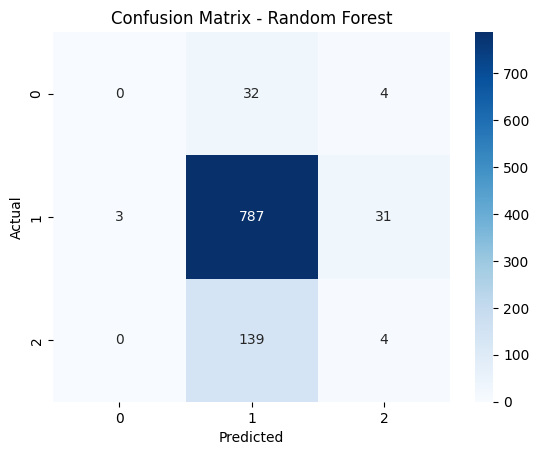

In [16]:
rf = models["Random Forest"]
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()
